<a href="https://colab.research.google.com/github/sasya05/quantum/blob/main/product_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q qiskit qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.8 MB/s eta 0:00:00


In [2]:
import random
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

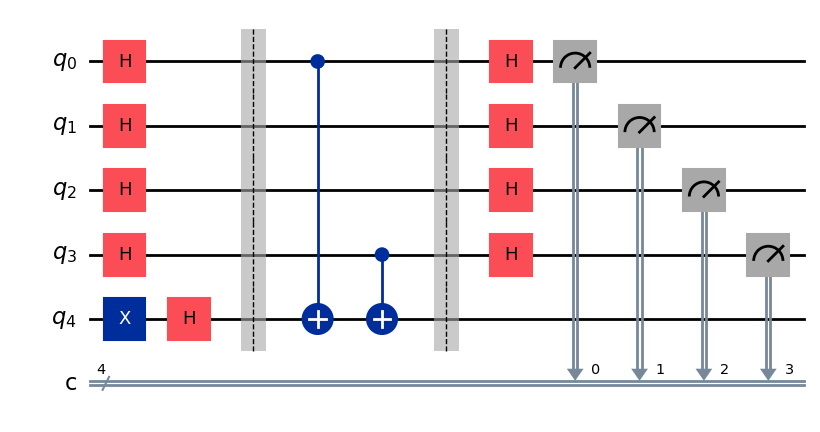

Result counts: {'1001': 1024}
Verdict: BALANCED (not all-zero output)


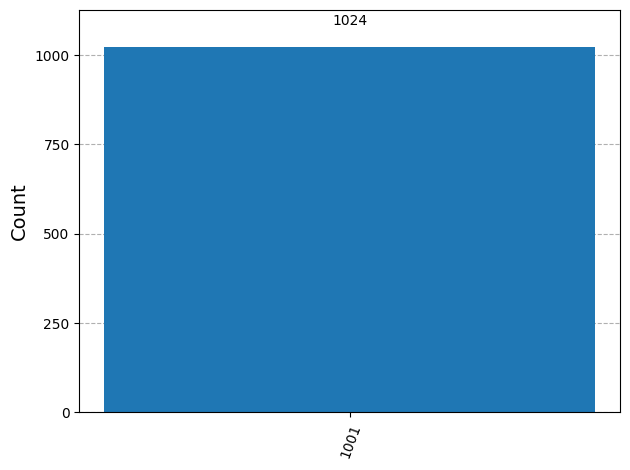

In [3]:
def dj_oracle(n, balanced=True):
    """Builds the oracle as a QuantumCircuit on n+1 qubits."""
    qc = QuantumCircuit(n + 1)
    if balanced:
        b = random.randint(1, 2**n - 1)
        for qubit in range(n):
            if (b >> qubit) & 1:
                qc.cx(qubit, n)
    else:
        if random.randint(0, 1):
            qc.x(n)
    return qc

def deutsch_jozsa_circuit(n, balanced=True):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()
    qc.compose(dj_oracle(n, balanced), inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

n = 4
dj_qc = deutsch_jozsa_circuit(n, balanced=True)
display(dj_qc.draw('mpl'))

tqc = transpile(dj_qc, sim)
counts = sim.run(tqc, shots=1024).result().get_counts()
print("Result counts:", counts)
print("Verdict:", "BALANCED (not all-zero output)" if '0'*n not in counts or len(counts) > 1 else "CONSTANT")
plot_histogram(counts)


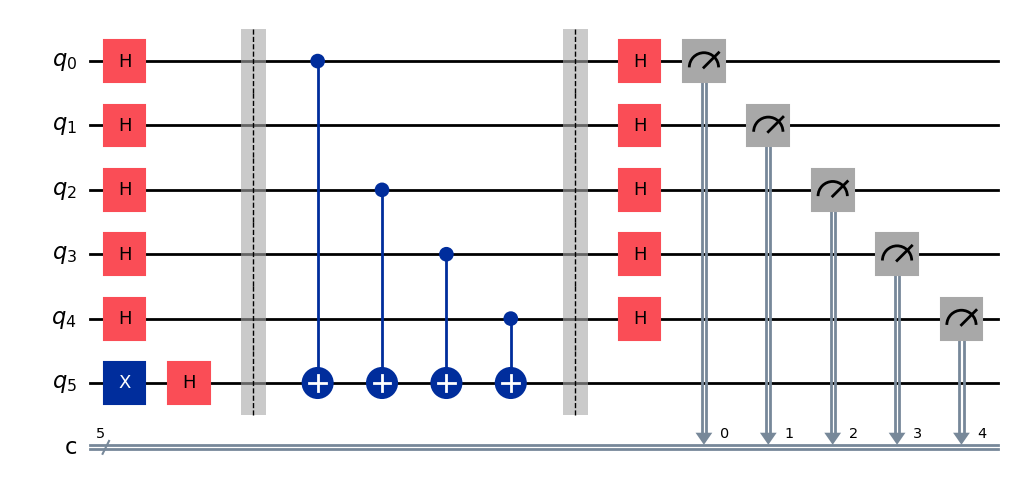

Hidden secret : 11101
Recovered     : 11101


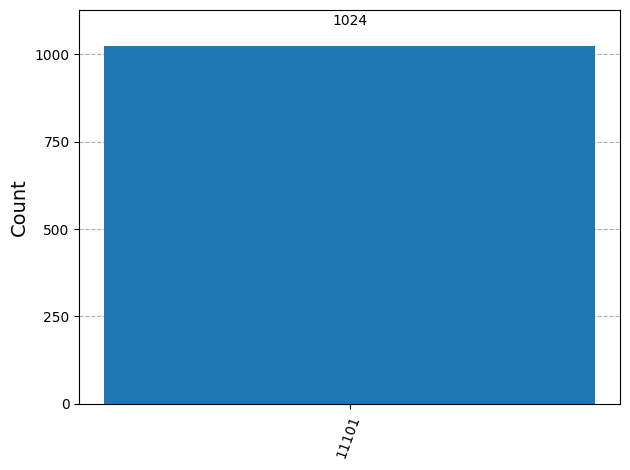

In [4]:
def bv_oracle(n, secret):
    qc = QuantumCircuit(n + 1)
    for qubit in range(n):
        if (secret >> qubit) & 1:
            qc.cx(qubit, n)
    return qc

def bernstein_vazirani_circuit(n, secret):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()
    qc.compose(bv_oracle(n, secret), inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

n = 5
secret = random.randint(1, 2**n - 1)
bv_qc = bernstein_vazirani_circuit(n, secret)
display(bv_qc.draw('mpl'))

tqc = transpile(bv_qc, sim)
counts = sim.run(tqc, shots=1024).result().get_counts()
recovered = list(counts.keys())[0]
print(f"Hidden secret : {format(secret, f'0{n}b')}")
print(f"Recovered     : {recovered}")
plot_histogram(counts)


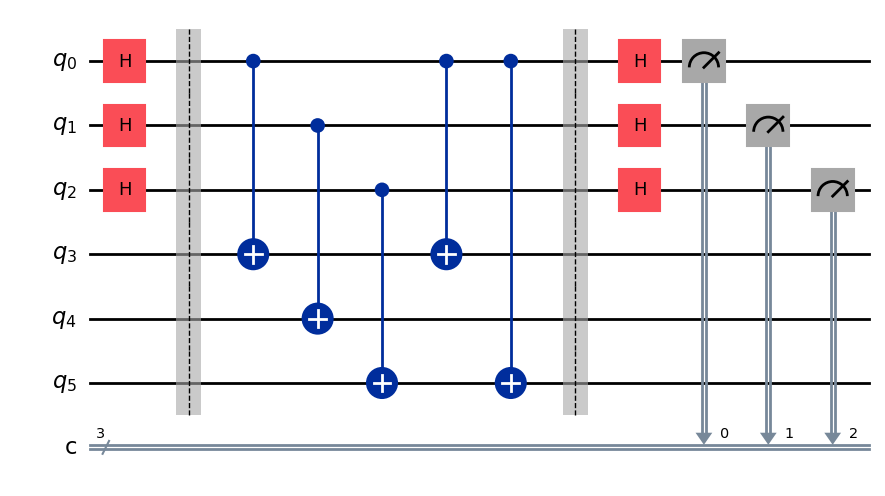

Independent equations collected: {'010', '111'}
Hidden secret : 101
Recovered     : 101


In [5]:
def simon_oracle(n, secret):
    qc = QuantumCircuit(2 * n)
    for i in range(n):
        qc.cx(i, n + i)
    if '1' in secret:
        j = secret.find('1')
        for i, bit in enumerate(secret):
            if bit == '1':
                qc.cx(j, n + i)
    return qc

def simon_circuit(n, secret):
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.barrier()
    qc.compose(simon_oracle(n, secret), inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

def solve_simon(equations, n):
    """Brute-force search over candidate secrets satisfying y . s = 0 for all y."""
    for candidate in range(1, 2**n):
        bits = [(candidate >> i) & 1 for i in range(n)]
        if all(sum(int(y[n - 1 - i]) * bits[i] for i in range(n)) % 2 == 0 for y in equations):
            return format(candidate, f'0{n}b')
    return None

n = 3
secret = "101"
equations = set()
attempts = 0
while len(equations) < n - 1 and attempts < 100:
    qc = simon_circuit(n, secret)
    tqc = transpile(qc, sim)
    y = list(sim.run(tqc, shots=1).result().get_counts().keys())[0]
    if y != '0' * n:
        equations.add(y)
    attempts += 1

display(simon_circuit(n, secret).draw('mpl'))
print("Independent equations collected:", equations)
print("Hidden secret :", secret)
print("Recovered     :", solve_simon(equations, n))


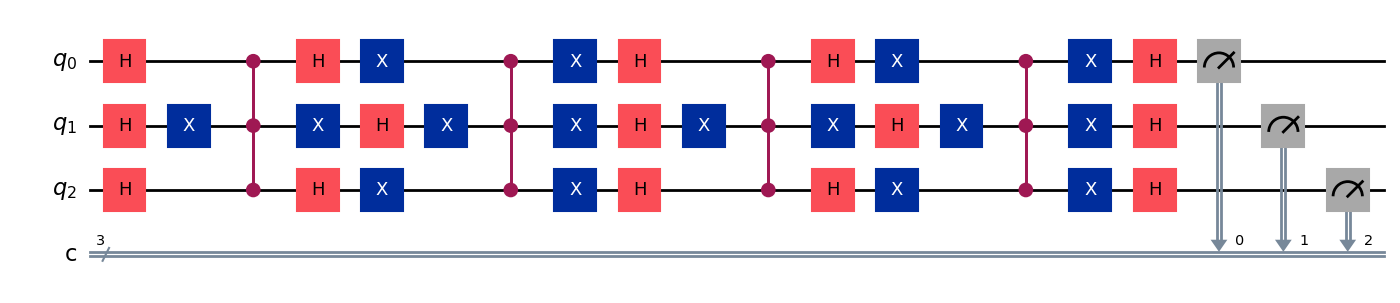

Iterations used: 2 (~pi/4 * sqrt(2^3))
Target: 101 | Most frequent result: 101


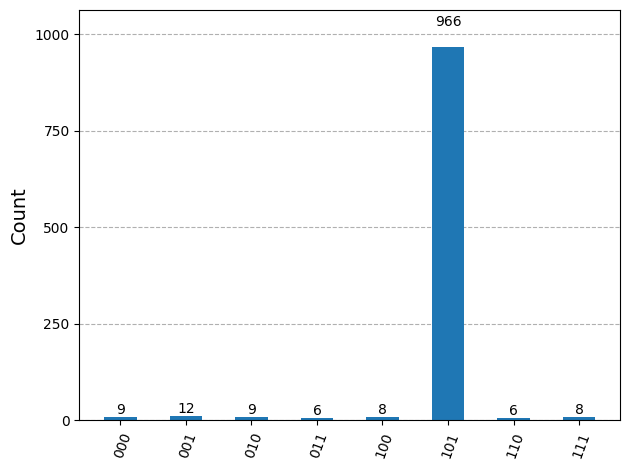

In [6]:
def grover_oracle(n, target):
    qc = QuantumCircuit(n)
    zeros = [i for i, b in enumerate(reversed(target)) if b == '0']
    if zeros:
        qc.x(zeros)
    qc.append(ZGate().control(n - 1), list(range(n)))
    if zeros:
        qc.x(zeros)
    return qc

def diffuser(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.append(ZGate().control(n - 1), list(range(n)))
    qc.x(range(n))
    qc.h(range(n))
    return qc

def grover_circuit(n, target, iterations):
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    for _ in range(iterations):
        qc.compose(grover_oracle(n, target), inplace=True)
        qc.compose(diffuser(n), inplace=True)
    qc.measure(range(n), range(n))
    return qc

n = 3
target = "101"
iterations = int(np.floor(np.pi / 4 * np.sqrt(2**n)))
grover_qc = grover_circuit(n, target, iterations)
display(grover_qc.draw('mpl'))

tqc = transpile(grover_qc, sim)
counts = sim.run(tqc, shots=1024).result().get_counts()
print(f"Iterations used: {iterations} (~pi/4 * sqrt(2^{n}))")
print("Target:", target, "| Most frequent result:", max(counts, key=counts.get))
plot_histogram(counts)


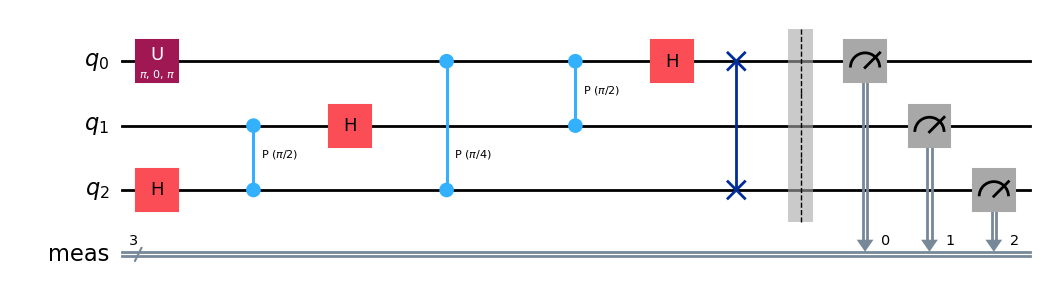

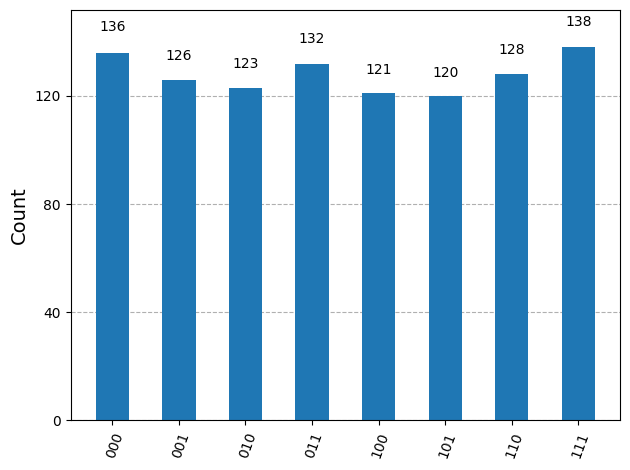

In [7]:
n = 3
qft_qc = QuantumCircuit(n)
qft_qc.x(0)  # prepare a simple input state
qft_qc.append(QFTGate(n), range(n))
qft_qc.measure_all()
display(qft_qc.decompose().draw('mpl'))

tqc = transpile(qft_qc, sim)
counts = sim.run(tqc, shots=1024).result().get_counts()
plot_histogram(counts)


In [8]:
def classical_dj(n, balanced, shots=None):
    # Worst case: must check up to 2^(n-1)+1 inputs to be sure
    calls = 0
    seen_outputs = set()
    max_calls = 2**(n - 1) + 1
    for x in range(2**n):
        calls += 1
        # simulate a query (dummy) -- correctness not needed, just counting queries
        if calls >= max_calls:
            break
    return calls

def classical_bv(n):
    return n  # one query per bit

def classical_simon_estimate(n):
    return int(np.ceil(2**(n / 2)))  # birthday bound, expected queries

def classical_grover(n):
    return 2**n  # linear scan worst case

rows = []
for n in [4, 8, 12, 16]:
    rows.append({
        "n": n,
        "DJ classical": classical_dj(n, True),
        "DJ quantum": 1,
        "BV classical": classical_bv(n),
        "BV quantum": 1,
        "Simon classical (~)": classical_simon_estimate(n),
        "Simon quantum (~n)": n,
        "Grover classical": classical_grover(n),
        "Grover quantum (~sqrt(N))": int(np.ceil(np.sqrt(2**n))),
    })

df = pd.DataFrame(rows)
df


,n,DJ classical,DJ quantum,BV classical,BV quantum,Simon classical (~),Simon quantum (~n),Grover classical,Grover quantum (~sqrt(N))
0,4,9,1,4,1,4,4,16,4
1,8,129,1,8,1,16,8,256,16
2,12,2049,1,12,1,64,12,4096,64
3,16,32769,1,16,1,256,16,65536,256


In [9]:
summary = pd.DataFrame([
    ["Deutsch-Jozsa", "O(2^(n-1)+1) worst case", "O(1)", "Exponential -> constant"],
    ["Bernstein-Vazirani", "O(n)", "O(1)", "Linear -> constant"],
    ["Simon's Algorithm", "O(2^(n/2))", "O(n)", "Exponential -> linear"],
    ["Grover's Search", "O(N) = O(2^n)", "O(sqrt(N)) = O(2^(n/2))", "Quadratic speedup"],
    ["QFT", "O(N log N) classical FFT", "O(n^2) gates, n = log2(N)", "Exponential gate-count advantage"],
], columns=["Algorithm", "Classical Complexity", "Quantum Complexity", "Speedup Type"])

summary

,Algorithm,Classical Complexity,Quantum Complexity,Speedup Type
0,Deutsch-Jozsa,O(2^(n-1)+1) worst case,O(1),Exponential -> constant
1,Bernstein-Vazirani,O(n),O(1),Linear -> constant
2,Simon's Algorithm,O(2^(n/2)),O(n),Exponential -> linear
3,Grover's Search,O(N) = O(2^n),O(sqrt(N)) = O(2^(n/2)),Quadratic speedup
4,QFT,O(N log N) classical FFT,"O(n^2) gates, n = log2(N)",Exponential gate-count advantage


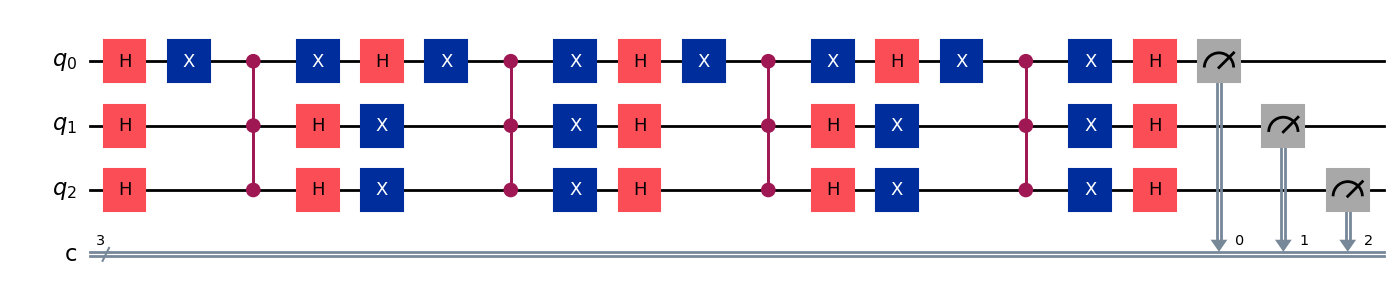

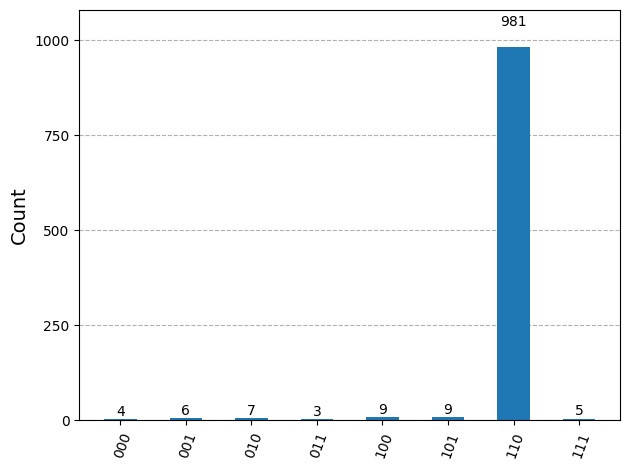

{'011': 3,
 '111': 5,
 '001': 6,
 '100': 9,
 '101': 9,
 '010': 7,
 '000': 4,
 '110': 981}

In [10]:
def run_algorithm(name, n=4, **kwargs):
    if name == "dj":
        qc = deutsch_jozsa_circuit(n, kwargs.get("balanced", True))
    elif name == "bv":
        secret = kwargs.get("secret", random.randint(1, 2**n - 1))
        qc = bernstein_vazirani_circuit(n, secret)
    elif name == "grover":
        target = kwargs.get("target", format(random.randint(0, 2**n - 1), f'0{n}b'))
        iters = int(np.floor(np.pi / 4 * np.sqrt(2**n)))
        qc = grover_circuit(n, target, iters)
    elif name == "qft":
        qc = QuantumCircuit(n)
        qc.x(0)
        qc.append(QFTGate(n), range(n))
        qc.measure_all()
    else:
        raise ValueError("Unknown algorithm. Choose from: dj, bv, grover, qft")

    tqc = transpile(qc, sim)
    counts = sim.run(tqc, shots=1024).result().get_counts()
    display(qc.draw('mpl'))
    display(plot_histogram(counts))
    return counts

# Example usage:
run_algorithm("grover", n=3, target="110")
